<a href="https://colab.research.google.com/github/kang25-gif/BA810/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab Notebook link:

# Homework 1 (Total 100 points)

#Homework 1

## Q1. Load and examine the `Auto.csv` dataset from the course folder on Google drive. **(10 points total)**

  1. Should you drop any variable from regression analysis and why? (5 points)
  1. Which variables should be treated as numeric and which as categorical? Explain why. (5 points)

Provide python code and analysis results first. Use them to support your answers to the two questions above.

FYI the column definitions (from https://cran.r-project.org/web/packages/ISLR/ISLR.pdf):
* mpg: miles per gallon (The outcome, or y, variable)
* cylinders: Number of cylinders between 4 and 8
* displacement: Engine displacement (cu. inches)
* horsepower: Engine horsepower
* weight: Vehicle weight (lbs.)
* acceleration: Time to accelerate from 0 to 60 mph (sec.)
* year: Model year (modulo 100)
* origin: Origin of car (1. American, 2. European, 3. Japanese)
* name: Vehicle name


In [2]:
import pandas as pd
from google.colab import drive

# made a shortcut of the BA810Material folder to mydrive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/BA810Material/Slides/Data/Auto.csv'
auto = pd.read_csv(path)
auto.head()


Mounted at /content/drive


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:

#show 'object in horsepower columns, need cleanning.
auto = auto.drop(columns=['name'])

auto.info()
auto.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 24.9+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397,397.000000,397.000000,397.000000,397.000000
unique,NaN,NaN,NaN,94,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,150,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,22,NaN,NaN,NaN,NaN
mean,23.515869,5.458438,193.532746,NaN,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,NaN,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,NaN,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,NaN,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,NaN,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,NaN,3609.000000,17.100000,79.000000,2.000000


In [4]:
auto['horsepower'] = auto['horsepower'].replace('?', pd.NA)
auto = auto.dropna(subset=['horsepower'])
auto['horsepower'] = auto['horsepower'].astype(float)

auto.info()
auto.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 27.6 KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [5]:
auto['cylinders'].unique()


array([8, 4, 6, 3, 5])

Answer:
1. I think variable 'name' is irrelevant for regression because it is neither not numeric and categorical variable. Which mean it will not fit in the function for regression. Also, for the variable 'origin' is possible to divide to multiple columns for better analysis, but NOT necessary.
2. mpg - Numeric, because it is fuel efficiency which mean is a continuous number
  **cylinders - Categorical**, there is only 3 type of engine(4, 6, 8)
  **displacement - Numeric**, it is a continuous number for size
  **horsepower - Numeric**, it is a continuous measure of engine power
  **weight - Numeric**, continuous number for weight
  **acceleration - Numeric**, continuous number for speed
  **year - Numeric**, continuous number of year, but treat in specific range
  **origin - Categorical**, 3 region (1. American, 2. European, 3. Japanese) which have no relation on number.


## Q2. Scatter and explore. **(20 points total)**
1. Plot all the pairwise scatter plots and histograms for the numeric features. (10 points)
1. Discuss two interesting relationships that you notice. (10 points)

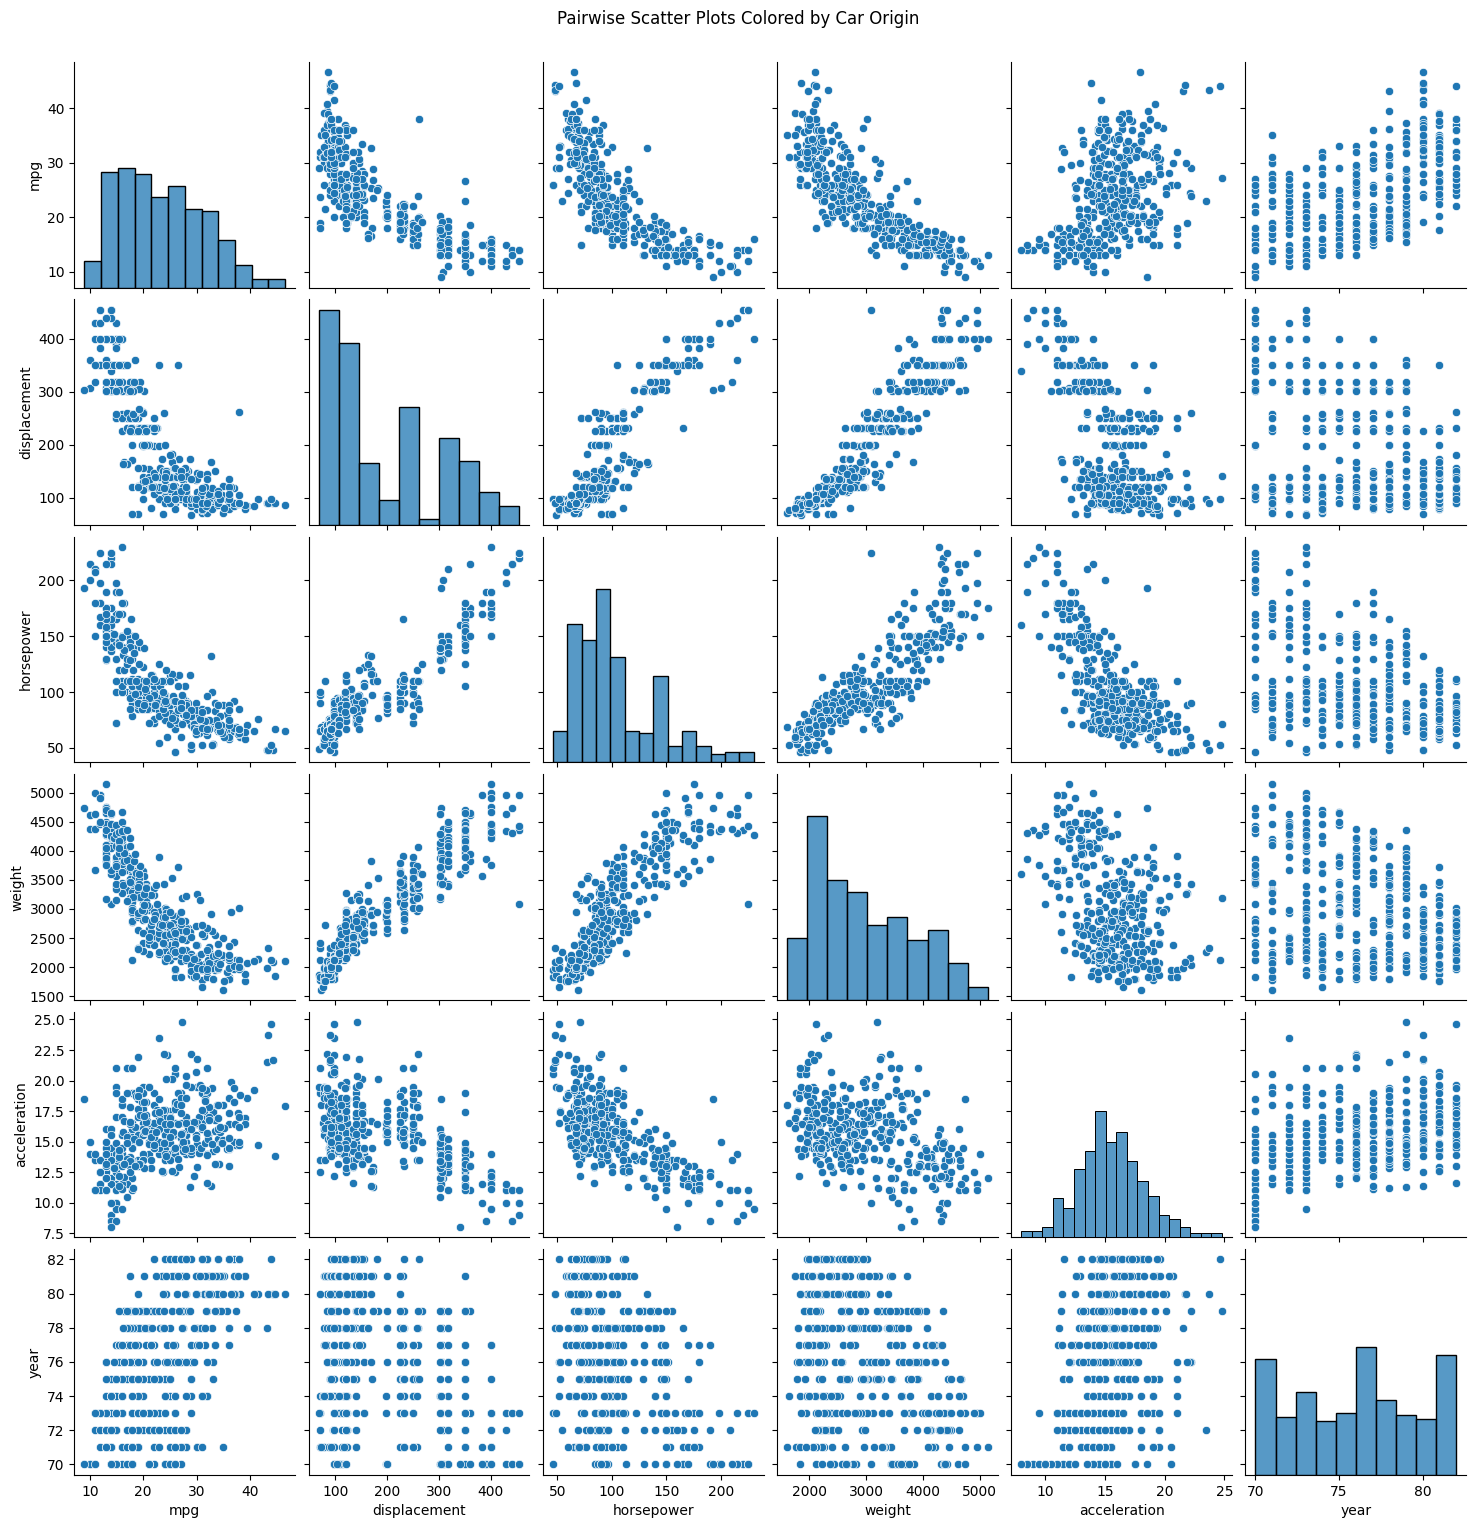

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(auto, vars=['mpg','displacement','horsepower','weight','acceleration','year'],
             diag_kind='hist')
plt.suptitle("Pairwise Scatter Plots Colored by Car Origin", y=1.02)
plt.show()


**Answer:**

First, we do see a strong netagitve correlation between mpg and (horsepower and weight). Which mean a low fuel efficiency will likely result a high horsepower and weight and vice versa.

Second, weight have a strong positive correlation with displacement and horsepower, which mean a higher weight will result a higher displacement and horsepower.

## Q3. Compute the correlation matrix among the numeric variables. Discuss one interesting correlation. (10+10=**20 points total**)

               mpg  cylinders  displacement  horsepower  weight  acceleration  \
mpg           1.00      -0.78         -0.81       -0.78   -0.83          0.42   
cylinders    -0.78       1.00          0.95        0.84    0.90         -0.50   
displacement -0.81       0.95          1.00        0.90    0.93         -0.54   
horsepower   -0.78       0.84          0.90        1.00    0.86         -0.69   
weight       -0.83       0.90          0.93        0.86    1.00         -0.42   
acceleration  0.42      -0.50         -0.54       -0.69   -0.42          1.00   
year          0.58      -0.35         -0.37       -0.42   -0.31          0.29   
origin        0.57      -0.57         -0.61       -0.46   -0.59          0.21   

              year  origin  
mpg           0.58    0.57  
cylinders    -0.35   -0.57  
displacement -0.37   -0.61  
horsepower   -0.42   -0.46  
weight       -0.31   -0.59  
acceleration  0.29    0.21  
year          1.00    0.18  
origin        0.18    1.00  


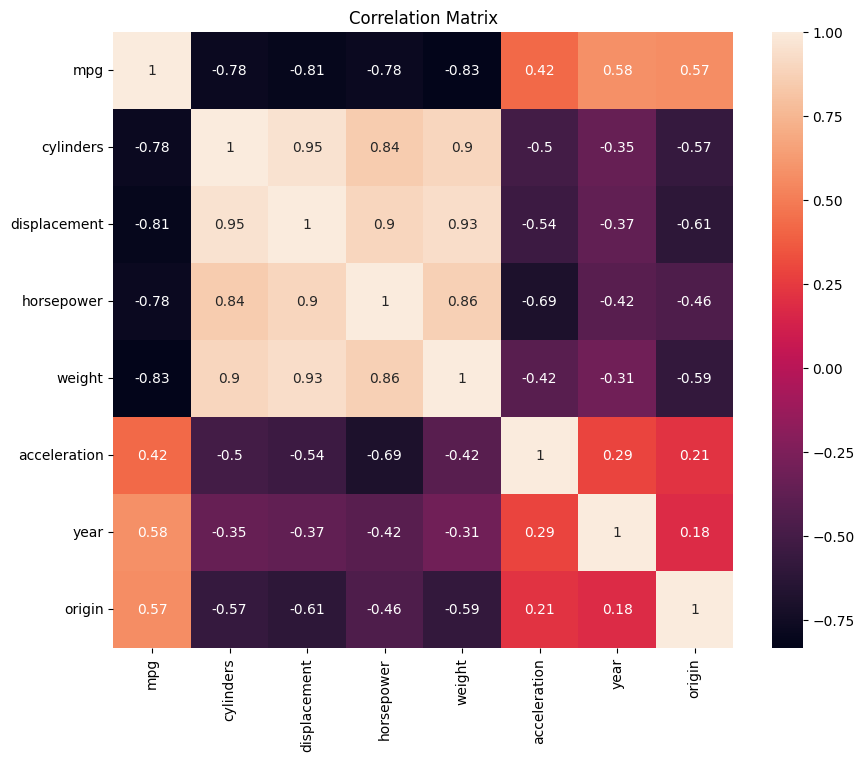

In [17]:
corr_matrix = auto.corr()
print(corr_matrix.round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

**Answer:**

We find that there is a r = -0.42 between acceleration and weight, which mean a higher weight will result a shorter time for 0 to 60 mph. The correlation is not strong but still now week. The resaon is that we need to balance the correlation because we can't ignore the influnce of horsepower, cylinders and displacement. These 3 variable have a medium to high correlation with both weight and acceleration, which mean it highly influence the correlation for weight and accelerration.

## Q4. Use `statsmodels` to regress mpg on all other variables. Note you can tell `ols()` to treat a variable as categorical by enclosing the variable in `C()`. **(15 points total)**
  1. Interpret the significant effects. (5 points)
  1. Which variables don't have a significant effect? Provide potential explanation for one surprising non-effect. (5 points)
  1. Discuss the difference in results when you treat `year` as a categorical vs a numeric variable. (5 points)

In [8]:
import statsmodels.formula.api as smf

model = smf.ols('mpg ~ C(cylinders) + displacement + horsepower + weight + acceleration + year + C(origin)', data=auto).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     191.1
Date:                Wed, 29 Oct 2025   Prob (F-statistic):          2.39e-147
Time:                        01:25:50   Log-Likelihood:                -993.35
No. Observations:                 392   AIC:                             2011.
Df Residuals:                     380   BIC:                             2058.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -22.0801      4.54

In [9]:
#test for different baseline

model_4base = smf.ols(
    'mpg ~ C(cylinders, Treatment(reference=8)) + displacement + horsepower + weight + acceleration + year + C(origin)',
    data=auto
).fit()

print(model_4base.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     191.1
Date:                Wed, 29 Oct 2025   Prob (F-statistic):          2.39e-147
Time:                        01:25:52   Log-Likelihood:                -993.35
No. Observations:                 392   AIC:                             2011.
Df Residuals:                     380   BIC:                             2058.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

1.
For cylinder(3 as baseline), all the coefficients are positive relative which mean it has higher MPG compare to 3 cylinder.

For origin(1.american as baseline), both asian and europe origin have a positive effect with MPG compare to 1.American.

It shows a slightly higher effect on MPG from displacement and acceleration.

It also has a slightly lower effect on MPG from both horsepowe and wight.

By the time of year, it has some higher effect on MPG.


2. cylinders with 6 and acceleration do not have a significant effect, p > 0.05
  
  !!! Right now I am not sure with the resaon for non-significant effect for cylinders with 6 as baseline of 3. I tried some different baseline, the result is (6 on 3), (5 and 8 on 4), (4, 6, 8 on 5), (3, 5 on 6) and (4 and 5 on 8). all of this X on Y mean X do not have significant effect when baseline is Y.
  
  For the reason acceleration, it is may becasue acceleration is high relate to other variable such as horsepower and displacement which is straight relate to MPG.




In [10]:
model = smf.ols('mpg ~ C(cylinders) + displacement + horsepower + weight + acceleration + C(year) + C(origin)', data=auto).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     116.8
Date:                Wed, 29 Oct 2025   Prob (F-statistic):          2.64e-151
Time:                        01:26:27   Log-Likelihood:                -954.59
No. Observations:                 392   AIC:                             1955.
Df Residuals:                     369   BIC:                             2047.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            30.9168      2.36

3. After we make year as categorical variables, we can find out all the cylinders become significant, but displacement and acceleration become non-significant, especially acceleration has p = 0.967. We also see some years from 71 - 76 are not significant.

## Q5. From the above regression model in Q4, include interactions between a numeric and categorical variable in three different regression models (three separate models in total). Do any of them appear significant? Discuss the results. **(15 points total)**


In [12]:

model1 = smf.ols('mpg ~ displacement * C(cylinders)', data=auto).fit()
print(model1.summary())

model2 = smf.ols('mpg ~ horsepower * C(origin)', data=auto).fit()
print(model2.summary())

model3 = smf.ols('mpg ~ acceleration * C(cylinders)', data=auto).fit()
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     108.3
Date:                Wed, 29 Oct 2025   Prob (F-statistic):           2.02e-99
Time:                        01:38:58   Log-Likelihood:                -1112.8
No. Observations:                 392   AIC:                             2246.
Df Residuals:                     382   BIC:                             2285.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

Answer:

We do see there is a significant result between horsepower and mpg base on the origin. Based on America,it has a higher drop on mpg in Japan and Europe when increase the same amount of horsepower. But for other 2 model, we can't have any significant result to make a conclusion.

## Q6. Measure the in-sample and out of sample $R^2$ of the model specified in Q4.1 using 80% data for training and 20% data for testing. **(10 points total)**

If you run into a problem because some values of a categorical column are missing in the training set, check the parameter `handle_unknown` for the OneHotEncoding class.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

D_train, D_test = train_test_split(auto, test_size=0.2, random_state=0)

est = smf.ols('mpg ~ C(cylinders) + displacement + horsepower + weight + acceleration + year + C(origin)', data=D_train).fit()

r2_train = est.rsquared

predictions = est.predict(D_test)
oos_r2 = r2_score(D_test['mpg'], predictions)

print("In-sample R²:", round(r2_train, 3))
print("Out-of-sample R²:", round(oos_r2, 3))


In-sample R²: 0.847
Out-of-sample R²: 0.844


## Q7. Collaboration statement **(10 points total)**
Who did you discuss while answering this homework (whether to get or to provide help)? What questions/topics did you discuss? Did you use any generative AI tool, such as ChatGPT? If so, provide your prompts.

Note: No penalty for either side. While getting help in figuring out how to solve is OK, all answers should be produced by you.

If you did not collaborate with anyone simply declare so.

Sample answer:

1. I discussed with Hazel for this homework. I needed her help with submission system and as a sounding board for the reasonableness of this homework.
2. I used ChatGPT with the following prompt to understand how to measure out of sample $R^2$:
> provide prompt here

Then I wrote the code that is submitted in the assignment.

3. I did not discuss with anyone or get any help from any generative AI tool.

1. I tell Kaixin about the problem I faced in Q4, which I can't not find the reason that cylinders 6 is not significant when cylinders 3 as baseline. But I just told him why I am confuse, I did not ask for any help or answer.
2. I used ChatGPT to give me some example for Q5, which I am not sure what is 'include interactions between a numeric and categorical variable in three different regression models' mean.
   
    Can you tell me what is 'include interactions between a numeric and categorical variable in three different regression models' mean is it mean use different regression models other than ols() or change the variable in ols('').


## Submit
1. Submit your colab notebook as a pdf file. Use the code in [this notebook](https://colab.research.google.com/drive/1ZZLCXbvUS3DEpZt9fgVVhZxWMxNigu2a?usp=sharing) to convert your notebook to professional looking pdf. Do review the pdf file to make sure everything is appearing correctly before submitting!
1. Include a link to the colab notebook in your submission and make sure to provide us (TAs and professor) access to view it.
